# Моделирование температуры сплава в тигель ковше
Выпускной проект

## Описание
Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Наша задача — построить модель, которая будет её предсказывать. 

## План работы

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка данных

In [2]:
def load_dataset(name, parse_dates=None, sep=',', decimal='.'):
	df = pd.DataFrame()
	try:
		df = pd.read_csv(f'./datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из локальной папки')
	except:
		df = pd.read_csv(f'https://code.s3.yandex.net/datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из облака')
	df.sort_index(inplace=True)
	return df

In [3]:
data_arc		= load_dataset('data_arc', parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
data_bulk		= load_dataset('data_bulk')
data_bulk_time	= load_dataset('data_bulk_time', parse_dates=list(range(1, data_bulk.shape[1] + 1)))
data_gas		= load_dataset('data_gas')
data_temp		= load_dataset('data_temp', parse_dates=[1])
data_wire		= load_dataset('data_wire')
data_wire_time	= load_dataset('data_wire_time', parse_dates=list(range(1, data_wire.shape[1] + 1)))

data_arc загружен из локальной папки
data_bulk загружен из локальной папки
data_bulk_time загружен из локальной папки
data_gas загружен из локальной папки
data_temp загружен из локальной папки
data_wire загружен из локальной папки
data_wire_time загружен из локальной папки


## Осмотр данных

In [4]:
"""
Рисует гистограмму и ящик с усами для количественных непрерывных признаков
"""
def plot_col(df, col, axs, cat_target):
	ax = sns.histplot(data=df, x=col, hue=cat_target, bins=50, ax=axs[0]);
	ax.set_title(col)
	ax.set_xlabel(None)
	ax = sns.boxplot(data=df, x=col, ax=axs[1]);
	ax.set_yticklabels([])
	ax.set_xlabel(None)

def plot_num_cont(df_raw, cols=None, cat_target=None):
	df = df_raw.reset_index(drop=True)
	if not cols: cols = df.select_dtypes(include='float64').columns
	row_count = len(cols)
	if row_count == 0:
		return
	fig, axs = plt.subplots(row_count, 2)
	fig.set_size_inches(12, 3 * row_count)
	if len(cols) == 1:
		plot_col(df, cols[0], axs, cat_target)
	else:
		row_idx = 0
		for col in cols:
			plot_col(df, col, axs[row_idx], cat_target)
			row_idx += 1

def explore_df(df):
	print('-' * 100)
	print('sample:')
	display(df.sample(5))
	print('-' * 100)
	print('\ninfo:\n')
	df.info()
	print('-' * 100)
	print('\ndescribe:\n')
	display(df.describe())
	print('-' * 100)
	print('\nduplicates:\n')
	print(f'id duplicates: {df.index.duplicated().sum()}, full row duplicates: {df.duplicated().sum()}')
	print('-' * 100)
	print('\nunique keys:\n')
	print(df.index.unique().size)
	plot_num_cont(df)

### data_arc
данные о нагреве электродами

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов

----------------------------------------------------------------------------------------------------
sample:


,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
key,,,,
1938,2019-07-20 04:25:48,2019-07-20 04:27:34,0.509656,0.375001
585,2019-05-25 17:04:23,2019-05-25 17:08:38,0.324714,0.219869
3084,2019-09-01 07:45:17,2019-09-01 07:49:31,0.588282,0.494323
2580,2019-08-13 21:33:48,2019-08-13 21:36:48,0.646635,0.574412
448,2019-05-20 12:27:20,2019-05-20 12:29:32,0.420118,0.316380


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 14876 entries, 1 to 3241
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Начало нагрева дугой  14876 non-null  datetime64[ns]
 1   Конец нагрева дугой   14876 non-null  datetime64[ns]
 2   Активная мощность     14876 non-null  float64       
 3   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2)
memory usage: 581.1 KB
----------------------------------------------------------------------------------------------------

describe:



,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
count,14876,14876,14876.000000,14876.000000
mean,2019-07-05 12:25:51.921081088,2019-07-05 12:28:43.592027392,0.662752,0.438986
min,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223120,-715.479924
25%,2019-06-03 23:18:23.249999872,2019-06-03 23:21:35,0.467115,0.337175
50%,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.599587,0.441639
75%,2019-08-07 22:52:20.750000128,2019-08-07 22:56:47,0.830070,0.608201
max,2019-09-06 17:24:54,2019-09-06 17:26:15,1.463773,1.270284
std,NaN,NaN,0.258885,5.873485


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 11662, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3214


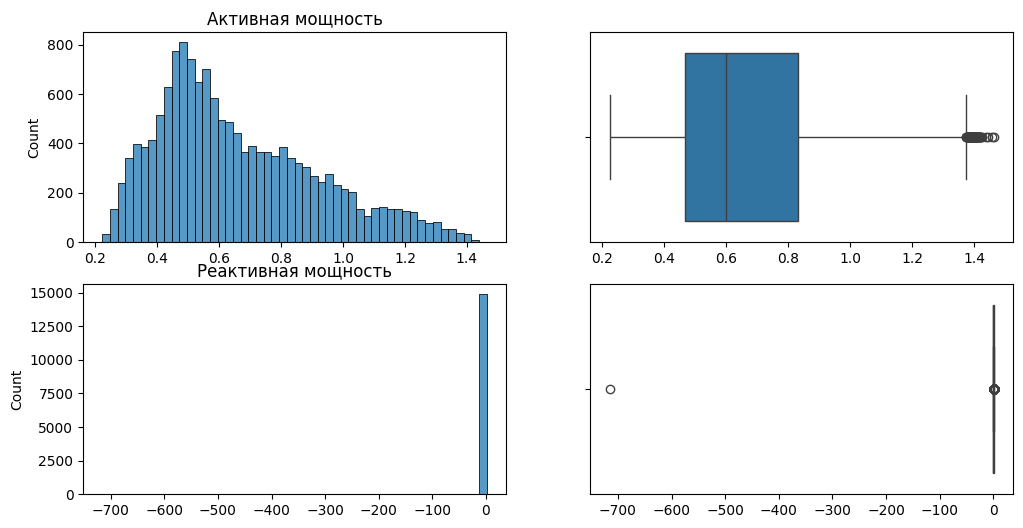

In [5]:
explore_df(data_arc)

- каждая запись - один цикл нагрева ковша с времением начала и конца и параметрами мощности
- по каждому ковшу как правило есть несколько записей - несколько циклов
- аномальный минимум в Реактивной мощности
- пропусков нет
- полных дубликатов нет

### data_bulk
данные о подаче сыпучих материалов (объём)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
1862,NaN,NaN,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119.0,NaN
1450,NaN,NaN,NaN,106.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,119.0,202.0
1477,NaN,NaN,NaN,52.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1435,NaN,NaN,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,309.0,NaN,201.0,199.0
2750,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.0,NaN,120.0,100.0


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Bulk 1   252 non-null    float64
 1   Bulk 2   22 non-null     float64
 2   Bulk 3   1298 non-null   float64
 3   Bulk 4   1014 non-null   float64
 4   Bulk 5   77 non-null     float64
 5   Bulk 6   576 non-null    float64
 6   Bulk 7   25 non-null     float64
 7   Bulk 8   1 non-null      float64
 8   Bulk 9   19 non-null     float64
 9   Bulk 10  176 non-null    float64
 10  Bulk 11  177 non-null    float64
 11  Bulk 12  2450 non-null   float64
 12  Bulk 13  18 non-null     float64
 13  Bulk 14  2806 non-null   float64
 14  Bulk 15  2248 non-null   float64
dtypes: float64(15)
memory usage: 391.1 KB
----------------------------------------------------------------------------------------------------

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 80
----------------------------------------------------------------------------------------------------

unique keys:

3129


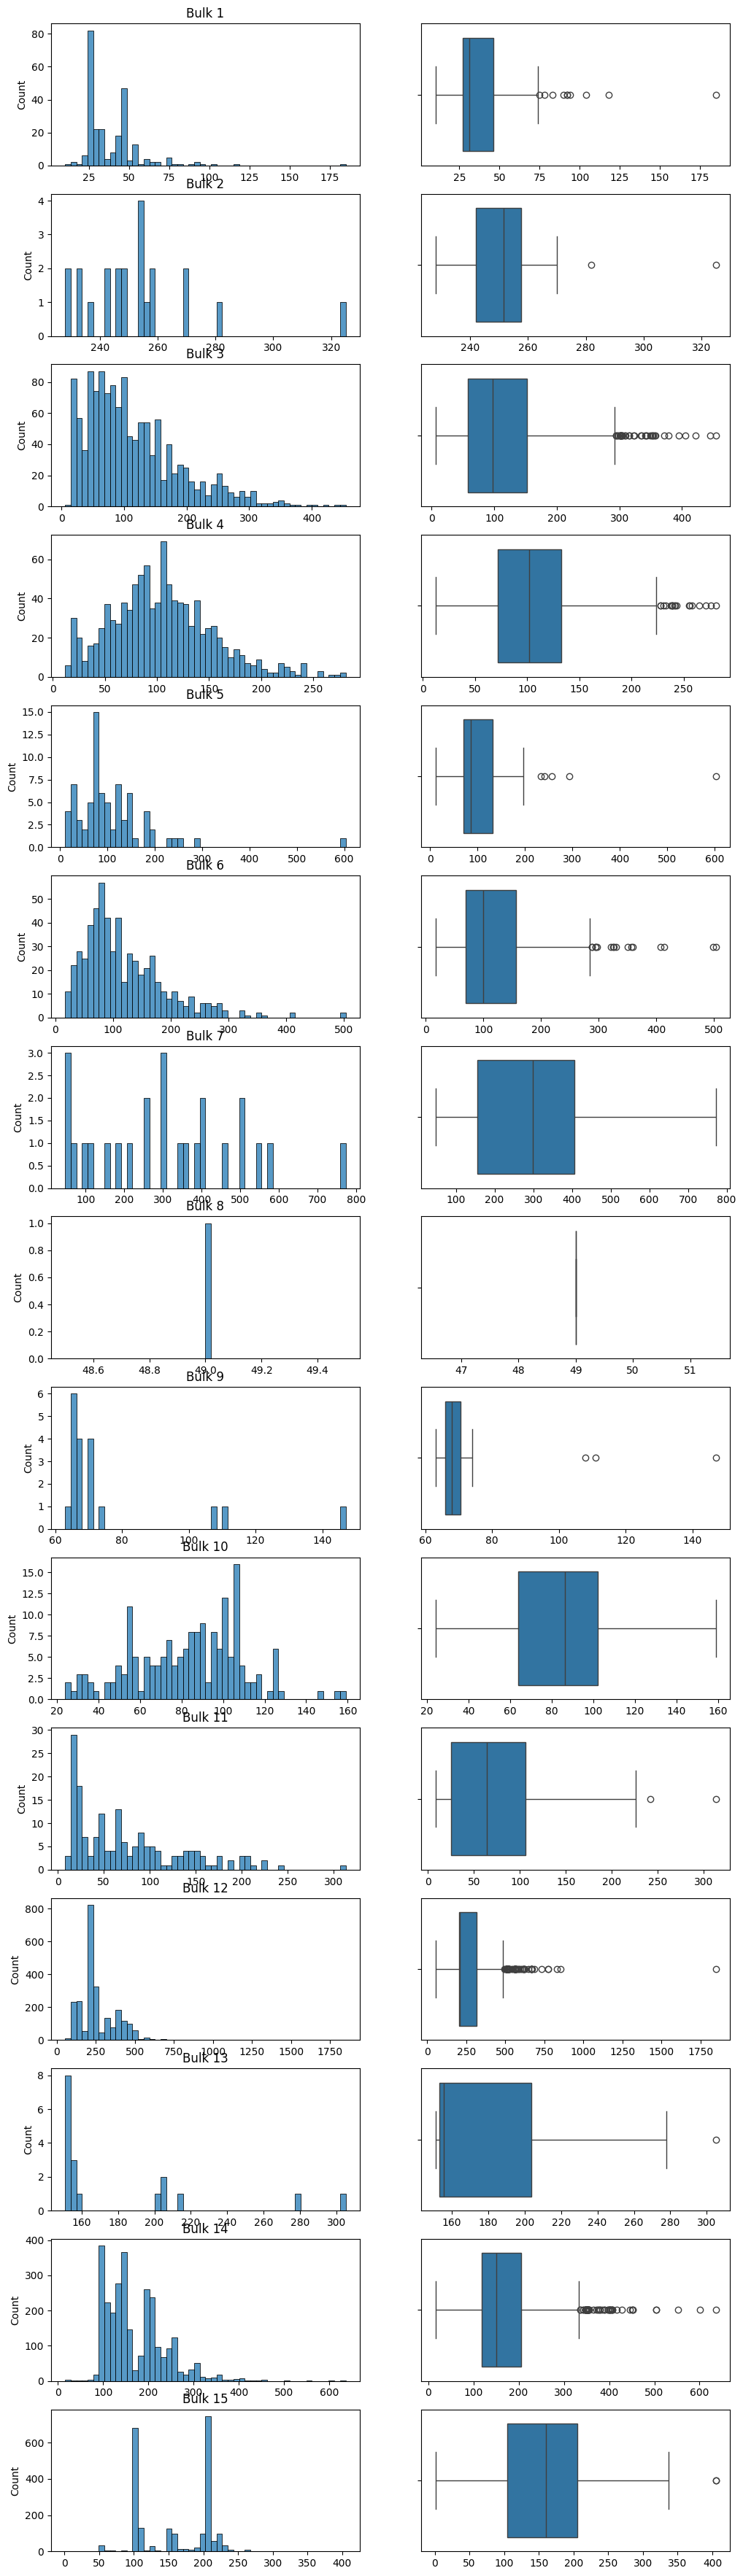

In [6]:
explore_df(data_bulk)

- здесь один ковш - одна запись. колонки по всей видимости соответствуют различным материалам - их поданному в ковш объему
- пропуски видимо значат, что такой материал не применялся, т.е. стоит заменить их на 0
- оценить здесь, что есть выбросы, без дополнительной информации сложно, но явных (отрицательных или огромных, нет)

### data_bulk_time
данные о подаче сыпучих материалов (время)

In [7]:
explore_df(data_bulk_time)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
1470,2019-06-27 22:02:59,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-06-27 21:50:53,NaT,2019-06-27 21:47:06,NaT,2019-06-27 21:41:04,2019-06-27 21:17:27
602,NaT,NaT,2019-05-26 06:51:18,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-26 06:51:18,NaT,2019-05-26 06:47:21,2019-05-26 06:40:57
1311,NaT,NaT,2019-06-21 21:15:16,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-06-21 21:04:27,NaT,2019-06-21 21:20:17,2019-06-21 21:15:16
2503,NaT,NaT,2019-08-10 16:41:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-08-10 16:31:00,NaT,2019-08-10 17:05:40,2019-08-10 16:54:46
1498,NaT,NaT,2019-06-28 19:05:41,NaT,NaT,NaT,NaT,NaT,NaT,2019-06-28 19:01:44,NaT,NaT,NaT,NaT,NaT


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Bulk 1   252 non-null    datetime64[ns]
 1   Bulk 2   22 non-null     datetime64[ns]
 2   Bulk 3   1298 non-null   datetime64[ns]
 3   Bulk 4   1014 non-null   datetime64[ns]
 4   Bulk 5   77 non-null     datetime64[ns]
 5   Bulk 6   576 non-null    datetime64[ns]
 6   Bulk 7   25 non-null     datetime64[ns]
 7   Bulk 8   1 non-null      datetime64[ns]
 8   Bulk 9   19 non-null     datetime64[ns]
 9   Bulk 10  176 non-null    datetime64[ns]
 10  Bulk 11  177 non-null    datetime64[ns]
 11  Bulk 12  2450 non-null   datetime64[ns]
 12  Bulk 13  18 non-null     datetime64[ns]
 13  Bulk 14  2806 non-null   datetime64[ns]
 14  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](1

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
mean,2019-06-29 23:24:44.769841152,2019-07-12 07:57:13.045454592,2019-07-08 13:50:14.630970624,2019-07-03 11:17:28.834319616,2019-07-13 17:18:29.090908928,2019-07-06 13:50:06.345486080,2019-07-27 18:09:05.079999744,2019-07-08 17:14:53,2019-06-23 08:08:47.578947328,2019-07-06 23:55:10.954545408,2019-07-15 07:01:00.615819264,2019-07-05 22:55:11.468571392,2019-07-01 18:32:46.944444416,2019-07-06 07:17:48.372772608,2019-07-06 13:24:51.912366336
min,2019-05-03 17:42:46,2019-05-07 15:39:35,2019-05-03 20:40:25,2019-05-03 11:28:48,2019-05-07 15:19:17,2019-05-03 19:09:15,2019-05-07 18:11:01,2019-07-08 17:14:53,2019-05-14 11:57:58,2019-05-06 07:54:02,2019-05-05 23:43:24,2019-05-03 11:24:31,2019-05-05 02:10:21,2019-05-03 11:14:50,2019-05-03 11:10:43
25%,2019-05-29 14:48:48.500000,2019-05-28 02:29:31.500000,2019-06-08 03:50:23.500000,2019-05-30 21:36:11.249999872,2019-06-19 23:32:44,2019-06-06 22:46:10.500000,2019-07-20 23:48:47,2019-07-08 17:14:53,2019-05-14 14:31:08,2019-06-02 05:12:00.500000,2019-06-14 20:24:48,2019-06-03 12:48:47.249999872,2019-05-29 10:43:31.249999872,2019-06-04 04:50:42,2019-06-04 11:28:18
50%,2019-06-25 11:09:13,2019-07-27 17:18:38.500000,2019-07-04 09:31:42,2019-06-28 03:44:42.500000,2019-07-25 17:59:41,2019-07-09 03:34:57.500000,2019-07-27 18:07:02,2019-07-08 17:14:53,2019-05-14 16:55:09,2019-07-06 07:05:20,2019-07-24 11:17:22,2019-07-03 01:32:00,2019-07-01 12:59:36.500000,2019-07-03 21:54:13.500000,2019-07-03 16:43:28.500000
75%,2019-07-31 05:58:18.249999872,2019-08-13 02:20:08,2019-08-11 01:00:36.750000128,2019-08-04 04:15:46.500000,2019-08-13 04:23:23,2019-08-07 18:55:01.249999872,2019-08-13 04:19:43,2019-07-08 17:14:53,2019-08-16 05:43:31,2019-08-04 02:23:35.750000128,2019-08-11 05:21:01,2019-08-08 14:55:05.249999872,2019-08-04 23:32:00.249999872,2019-08-09 04:22:40.500000,2019-08-09 09:18:31.750000128
max,2019-09-05 09:11:32,2019-08-13 11:47:39,2019-09-06 12:26:52,2019-09-05 03:35:21,2019-09-02 18:16:52,2019-09-06 16:24:28,2019-09-05 19:07:49,2019-07-08 17:14:53,2019-08-16 09:11:56,2019-09-04 10:03:22,2019-09-06 05:03:14,2019-09-06 15:01:44,2019-09-01 01:53:02,2019-09-06 17:26:33,2019-09-06 17:23:15


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3129


- у data_bulk_time структура такая же, как у data_bulk

### data_gas
данные о продувке сплава газом

----------------------------------------------------------------------------------------------------
sample:


,Газ 1
key,
1026,8.910542
3164,7.620290
1173,4.109690
2995,13.578719
37,13.607961


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3239 entries, 1 to 3241
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Газ 1   3239 non-null   float64
dtypes: float64(1)
memory usage: 50.6 KB
----------------------------------------------------------------------------------------------------

describe:



,Газ 1
count,3239.000000
mean,11.002062
std,6.220327
min,0.008399
25%,7.043089
50%,9.836267
75%,13.769915
max,77.995040


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3239


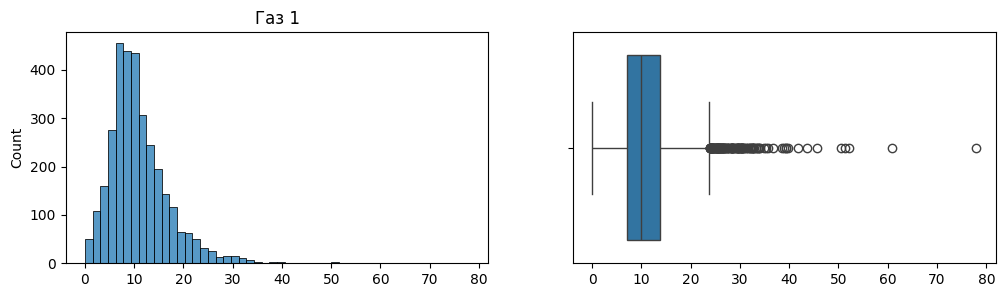

In [8]:
explore_df(data_gas)

- data_gas - просто какой объем газа (видимо, в сумме) был продут через каждый ковш
- дубликатов нет
- лакун нет
- явных выбросов нет

### data_temp
результаты измерения температуры

----------------------------------------------------------------------------------------------------
sample:


,Время замера,Температура
key,,
2332,2019-08-04 08:17:44,1596.0
2424,2019-08-07 19:58:11,1557.0
1759,2019-07-07 22:19:07,1578.0
2965,2019-08-28 03:28:19,NaN
1866,2019-07-11 16:10:19,1604.0


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 18092 entries, 1 to 3241
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Время замера  18092 non-null  datetime64[ns]
 1   Температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 424.0 KB
----------------------------------------------------------------------------------------------------

describe:



,Время замера,Температура
count,18092,14665.000000
mean,2019-07-05 13:36:58.791620608,1590.722741
min,2019-05-03 11:02:04,1191.000000
25%,2019-06-04 00:35:01.249999872,1580.000000
50%,2019-07-03 02:11:48,1590.000000
75%,2019-08-07 23:10:05.249999872,1599.000000
max,2019-09-06 17:30:05,1705.000000
std,NaN,20.394381


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 14876, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3216


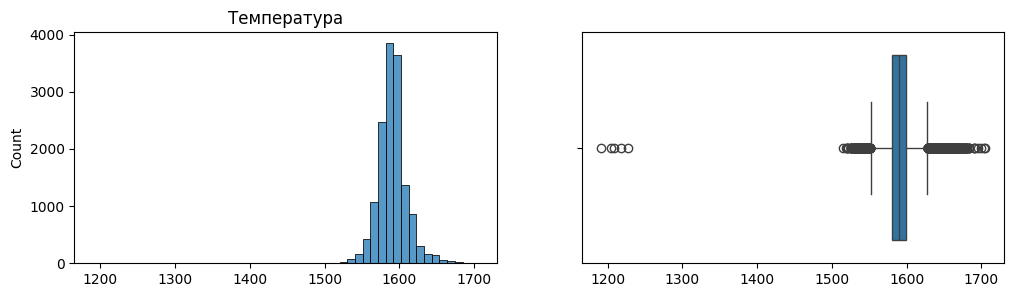

In [9]:
explore_df(data_temp)

- в data_temp каждая запись - один замер (время и температура). как правило по несколько замеров для каждого ковша.
- есть лакуны в поле температуры
- есть значения заведомо ниже температуры плавления сплава (~1400), чего быть не должно - сплав застынет и все - будем считать выбросами
- если не считать выбросы, распределение похоже на нормальное с чуть более вытянутым хвостом в сторону высоких температур

### data_wire
данные о проволочных материалах (объём)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
1090,160.102799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2556,52.110241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
553,152.334000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3045,28.173599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2210,101.119202,103.177353,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Wire 1  3055 non-null   float64
 1   Wire 2  1079 non-null   float64
 2   Wire 3  63 non-null     float64
 3   Wire 4  14 non-null     float64
 4   Wire 5  1 non-null      float64
 5   Wire 6  73 non-null     float64
 6   Wire 7  11 non-null     float64
 7   Wire 8  19 non-null     float64
 8   Wire 9  29 non-null     float64
dtypes: float64(9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:



,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 403
----------------------------------------------------------------------------------------------------

unique keys:

3081


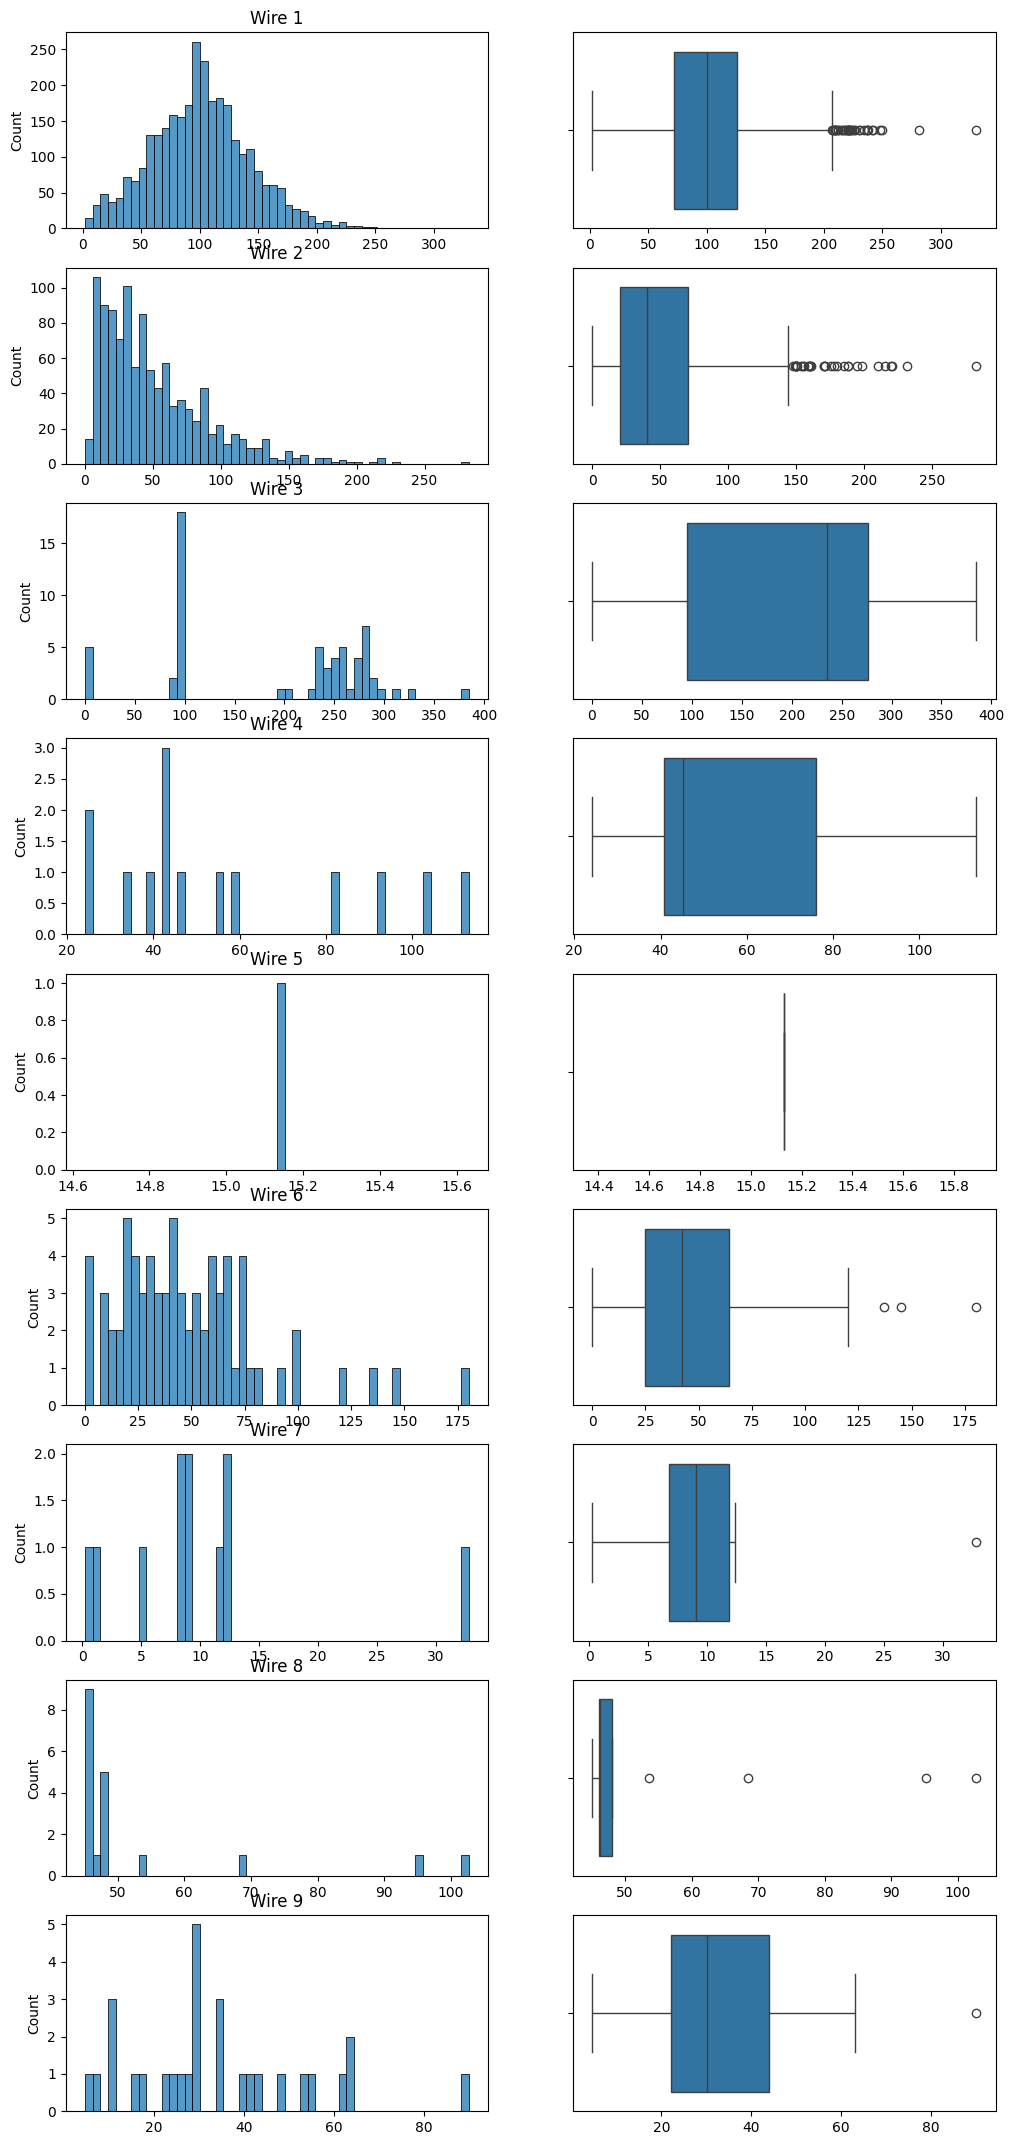

In [10]:
explore_df(data_wire)

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов

### data_wire_time
данные о проволочных материалах (время)

In [11]:
explore_df(data_wire_time)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
3020,2019-08-30 03:05:47,2019-08-30 02:53:33,NaT,NaT,NaT,NaT,NaT,NaT,NaT
318,2019-05-15 16:46:36,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2419,2019-08-07 17:22:59,2019-08-07 17:16:11,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2751,2019-08-19 23:21:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2310,2019-08-03 15:18:11,2019-08-03 15:16:06,NaT,NaT,NaT,NaT,NaT,NaT,NaT


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Wire 1  3055 non-null   datetime64[ns]
 1   Wire 2  1079 non-null   datetime64[ns]
 2   Wire 3  63 non-null     datetime64[ns]
 3   Wire 4  14 non-null     datetime64[ns]
 4   Wire 5  1 non-null      datetime64[ns]
 5   Wire 6  73 non-null     datetime64[ns]
 6   Wire 7  11 non-null     datetime64[ns]
 7   Wire 8  19 non-null     datetime64[ns]
 8   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:



,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055,1079,63,14,1,73,11,19,29
mean,2019-07-05 23:22:34.279541760,2019-07-07 01:07:08.735866624,2019-07-10 15:09:58.650793472,2019-07-11 13:44:37,2019-08-13 06:14:30,2019-07-07 11:51:15.095890432,2019-08-07 01:16:08.090909184,2019-06-23 07:47:49.052631552,2019-07-01 11:56:04.793103616
min,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
25%,2019-06-04 19:30:11.500000,2019-06-05 14:50:26.500000,2019-06-11 14:17:38.500000,2019-07-20 17:58:53.750000128,2019-08-13 06:14:30,2019-05-08 21:47:30,2019-07-27 16:27:27,2019-05-14 14:20:07.500000,2019-06-09 19:36:17
50%,2019-07-03 06:36:23,2019-07-04 23:13:39,2019-07-21 10:04:47,2019-07-27 05:45:26.500000,2019-08-13 06:14:30,2019-07-28 05:00:32,2019-08-12 21:48:11,2019-05-14 16:55:09,2019-06-11 10:10:21
75%,2019-08-08 08:56:06.500000,2019-08-08 23:15:17,2019-08-12 22:54:46,2019-07-27 16:20:04.750000128,2019-08-13 06:14:30,2019-08-13 13:33:02,2019-08-13 02:02:55.500000,2019-08-16 05:06:53.500000,2019-08-09 06:49:04
max,2019-09-06 17:10:06,2019-09-06 07:35:40,2019-09-02 07:14:44,2019-08-13 03:16:45,2019-08-13 06:14:30,2019-08-18 19:10:56,2019-08-13 10:25:22,2019-08-16 08:56:23,2019-09-03 12:55:23


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3081


- data_wire_time - то же самое, что для data_wire

### Общие выводы по данным
- Есть две очевидные аномалии:
  - очень низкое значение в реактивной мощности
  - есть значения заведомо ниже температуры плавления сплава (~1400)
- Пропуски для bulk и wire надо заменить нулями
- Характер распределений здесь кроме температуры, наверное, описывать смысла нет, т.к. он определяется технологией процесса
- Желательно переименовать колонки в общепринятом стиле
- Хорошо бы найти метод определить время начала работы с ковшом, тогда можно попробовать перевести все времена для ковша в относительные к времени начала
- Для нагрева электродами можно посчитать продолжительность цикла и работу (активная мощность * продолжительность)
- Реактивная мощность по идее не должна влиять на температуру. Только на затраты энергии.

## Предобработка данных
### Переименования колонок

In [12]:
data_arc.columns = ['arc_start_time', 'arc_end_time', 'arc_acive_power', 'arc_reacive_power']
data_bulk.columns = [f'bulk_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_bulk_time.columns = [f'bulk_time_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_gas.columns = ['gas_1']
data_temp.columns = ['temp_time', 'temp']
data_wire.columns = [f'wire_{x:02}' for x in range(1, data_wire.shape[1] + 1)]
data_wire_time.columns = [f'wire_time_{x:02}' for x in range(1, data_wire.shape[1] + 1)]

for df in [data_arc, data_bulk, data_bulk_time, data_gas, data_temp, data_wire, data_wire_time]:
	print(df.columns)

Index(['arc_start_time', 'arc_end_time', 'arc_acive_power',
       'arc_reacive_power'],
      dtype='object')
Index(['bulk_01', 'bulk_02', 'bulk_03', 'bulk_04', 'bulk_05', 'bulk_06',
       'bulk_07', 'bulk_08', 'bulk_09', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')
Index(['bulk_time_01', 'bulk_time_02', 'bulk_time_03', 'bulk_time_04',
       'bulk_time_05', 'bulk_time_06', 'bulk_time_07', 'bulk_time_08',
       'bulk_time_09', 'bulk_time_10', 'bulk_time_11', 'bulk_time_12',
       'bulk_time_13', 'bulk_time_14', 'bulk_time_15'],
      dtype='object')
Index(['gas_1'], dtype='object')
Index(['temp_time', 'temp'], dtype='object')
Index(['wire_01', 'wire_02', 'wire_03', 'wire_04', 'wire_05', 'wire_06',
       'wire_07', 'wire_08', 'wire_09'],
      dtype='object')
Index(['wire_time_01', 'wire_time_02', 'wire_time_03', 'wire_time_04',
       'wire_time_05', 'wire_time_06', 'wire_time_07', 'wire_time_08',
       'wire_time_09'],
      dty